# Module 3 — Statistical Estimation & Inference

In Notebook 1 we *summarised* returns. In Notebook 2 we *modelled* them. This notebook asks an uncomfortable question about every statistic we compute:

> **How confident can we really be in that number?**

We'll work **only with weekly returns** this time, and deliberately construct them in **two different ways**:

- **Method A — Friday-close weekly returns.** One return per week, using the Friday closing price. Non-overlapping.
- **Method B — 5-day rolling weekly returns.** A weekly return computed for *every* trading day, looking 5 days back. Heavily overlapping.

Both methods target the same quantity (the expected weekly return) but yield samples of very different size — and, as we'll see, very different *effective* information content.

Section A walks through the full inference toolkit — point estimators, sampling variability, confidence intervals, hypothesis tests — using the clean Friday-close series. Section B re-runs the same machinery on the rolling series to expose a classic pitfall: **overlapping observations give the illusion of more precision than they actually provide**.

Two stocks throughout: **SBI** and **Yes Bank**. Step by step.


## 0. Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.precision', 4)
np.random.seed(42)   # reproducible bootstrap samples


## 1. Load the data and build both weekly return series


### 1.1  Load and clean SBI


In [2]:
sbi = pd.read_csv('datasets/daily/sbi.csv')
sbi['Date'] = pd.to_datetime(sbi['Date'], format='%d-%B-%Y')
sbi = sbi.sort_values('Date').set_index('Date')
sbi.head()


,Open Price,High Price,Low Price,Close Price,WAP,No.of Shares,No. of Trades,Total Turnover (Rs.),Deliverable Quantity,% Deli. Qty to Traded Qty,Spread High-Low,Spread Close-Open
Date,,,,,,,,,,,,
2025-04-30,812.85,812.85,784.45,788.15,792.8184,412886,13571,3.2734e+08,157049,38.04,28.40,-24.70
2025-05-02,792.05,802.95,789.25,800.05,795.9029,335006,8100,2.6663e+08,97358,29.06,13.70,8.00
2025-05-05,784.95,799.10,783.65,790.00,789.7475,771587,22047,6.0936e+08,292169,37.87,15.45,5.05
2025-05-06,792.20,799.00,771.15,774.15,778.2487,761282,23690,5.9247e+08,309770,40.69,27.85,-18.05
2025-05-07,762.25,782.55,762.25,776.15,775.8552,581175,14757,4.5091e+08,235513,40.52,20.30,13.90


### 1.2  Load and clean Yes Bank


In [3]:
yesbank = pd.read_csv('datasets/daily/YesBank.csv')
yesbank['Date'] = pd.to_datetime(yesbank['Date'], format='%d-%B-%Y')
yesbank = yesbank.sort_values('Date').set_index('Date')
yesbank.head()


,Open Price,High Price,Low Price,Close Price,WAP,No.of Shares,No. of Trades,Total Turnover (Rs.),Deliverable Quantity,% Deli. Qty to Traded Qty,Spread High-Low,Spread Close-Open
Date,,,,,,,,,,,,
2025-04-30,17.96,18.03,17.66,17.72,17.8296,7721231,17056,1.3767e+08,4.1017e+06,53.12,0.37,-0.24
2025-05-02,17.69,17.99,17.61,17.71,17.8084,7591714,16051,1.3520e+08,2.7774e+06,36.58,0.38,0.02
2025-05-05,17.71,17.84,17.51,17.73,17.7039,6614205,16396,1.1710e+08,2.7459e+06,41.51,0.33,0.02
2025-05-06,19.24,19.44,17.88,17.94,18.4596,39392027,41979,7.2716e+08,1.1603e+07,29.46,1.56,-1.30
2025-05-07,17.81,18.38,17.72,18.27,18.0418,17618432,24598,3.1787e+08,6.5962e+06,37.44,0.66,0.46


### 1.3  Method A — Friday-close weekly returns

`resample('W-FRI').last()` picks one closing price per calendar week (Friday's close, or the last trading day of that week). Applying `pct_change()` then gives a **non-overlapping** weekly return series: one return per week.


In [4]:
sbi_weekly_fri     = sbi['Close Price'].resample('W-FRI').last().pct_change().dropna()
yesbank_weekly_fri = yesbank['Close Price'].resample('W-FRI').last().pct_change().dropna()

print(f'SBI Friday-close weekly:     n = {len(sbi_weekly_fri):4d}')
print(f'Yes Bank Friday-close weekly: n = {len(yesbank_weekly_fri):4d}')
sbi_weekly_fri.head()


SBI Friday-close weekly:     n =   51
Yes Bank Friday-close weekly: n =   51


Date
2025-05-09   -0.0258
2025-05-16    0.0160
2025-05-23   -0.0018
2025-05-30    0.0278
2025-06-06    0.0006
Freq: W-FRI, Name: Close Price, dtype: float64

---

# SECTION A — Inference on Friday-close weekly returns

This is our "honest" path. Observations are non-overlapping, so the iid-with-finite-variance assumption underlying classical SEs and t-tests is defensible. We'll build the full inference toolkit on this series.


## A.2  Point estimators

Given a sample $r_1, \ldots, r_n$, the standard estimators of the true mean and variance are

$$
\hat{\mu} = \bar{r} = \frac{1}{n} \sum r_i,
\qquad
\hat{\sigma}^2 = s^2 = \frac{1}{n - 1} \sum (r_i - \bar{r})^2
$$

The $n - 1$ makes $s^2$ **unbiased** — its expected value equals $\sigma^2$. `.var()` and `.std()` use $n-1$ by default.


### A.2.1  Point estimates — SBI


In [5]:
mu_sbi    = sbi_weekly_fri.mean()
sigma_sbi = sbi_weekly_fri.std()
n_sbi     = len(sbi_weekly_fri)
print(f'SBI Friday-close weekly:')
print(f'  n     = {n_sbi}')
print(f'  mean  = {mu_sbi:+.6f}  ({mu_sbi*100:+.3f}% per week)')
print(f'  std   = {sigma_sbi:.6f}')


SBI Friday-close weekly:
  n     = 51
  mean  = +0.006903  (+0.690% per week)
  std   = 0.029630


### A.2.2  Point estimates — Yes Bank


In [6]:
mu_yb    = yesbank_weekly_fri.mean()
sigma_yb = yesbank_weekly_fri.std()
n_yb     = len(yesbank_weekly_fri)
print(f'Yes Bank Friday-close weekly:')
print(f'  n     = {n_yb}')
print(f'  mean  = {mu_yb:+.6f}  ({mu_yb*100:+.3f}% per week)')
print(f'  std   = {sigma_yb:.6f}')


Yes Bank Friday-close weekly:
  n     = 51
  mean  = +0.002988  (+0.299% per week)
  std   = 0.041597


## A.3  Sampling variability — standard error of the mean

If we collected a different year of weekly returns we'd get a different $\bar{r}$. The standard deviation of $\bar{r}$ across hypothetical re-samples is the **standard error**:

$$
\text{SE}(\bar{r}) = \sigma / \sqrt{n}.
$$

In practice we replace $\sigma$ with its sample estimate $s$.


### A.3.1  Analytical SE — SBI and Yes Bank


In [7]:
se_sbi = sigma_sbi / np.sqrt(n_sbi)
se_yb  = sigma_yb  / np.sqrt(n_yb)
print(f'SBI SE (s/√n):      {se_sbi:.6f}')
print(f'Yes Bank SE (s/√n): {se_yb:.6f}')


SBI SE (s/√n):      0.004149
Yes Bank SE (s/√n): 0.005825


### A.3.2  Bootstrap SE — resample, compute mean, repeat

The bootstrap is a model-free way to measure sampling variability:

1. Draw a resample of size $n$ from the data **with replacement**.
2. Compute the mean of that resample.
3. Repeat many times.
4. The standard deviation of the resampled means is the **bootstrap SE**.


In [8]:
n_boot = 10_000
boot_means_sbi = np.zeros(n_boot)

for i in range(n_boot):
    resample = sbi_weekly_fri.sample(n=n_sbi, replace=True)
    boot_means_sbi[i] = resample.mean()

print(f'SBI:')
print(f'  Analytical SE (s/√n): {se_sbi:.6f}')
print(f'  Bootstrap SE:         {boot_means_sbi.std(ddof=1):.6f}')
print(f'  Bootstrap mean-of-means: {boot_means_sbi.mean():+.6f}   (≈ original mean {mu_sbi:+.6f})')


SBI:
  Analytical SE (s/√n): 0.004149
  Bootstrap SE:         0.004134
  Bootstrap mean-of-means: +0.006856   (≈ original mean +0.006903)


The two SEs agree closely — good news for the analytical formula on this data.


### A.3.3  Same bootstrap for Yes Bank


In [9]:
boot_means_yb = np.zeros(n_boot)
for i in range(n_boot):
    resample = yesbank_weekly_fri.sample(n=n_yb, replace=True)
    boot_means_yb[i] = resample.mean()

print(f'Yes Bank:')
print(f'  Analytical SE (s/√n): {se_yb:.6f}')
print(f'  Bootstrap SE:         {boot_means_yb.std(ddof=1):.6f}')


Yes Bank:
  Analytical SE (s/√n): 0.005825
  Bootstrap SE:         0.005710


### A.3.4  Visualise the bootstrap sampling distributions


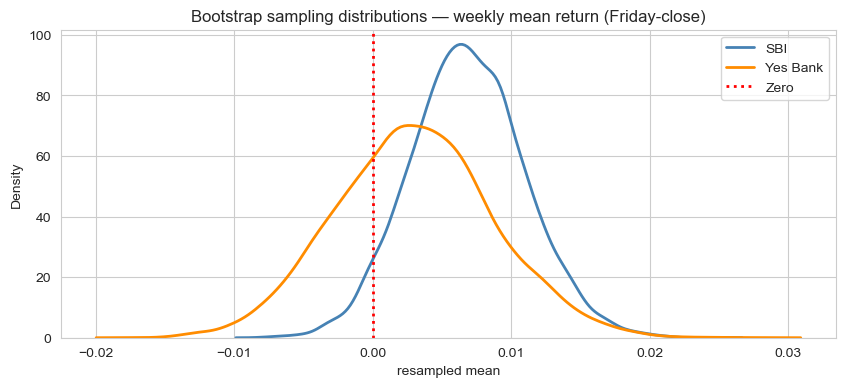

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.kdeplot(boot_means_sbi, label='SBI',      ax=ax, linewidth=2, color='steelblue')
sns.kdeplot(boot_means_yb,  label='Yes Bank', ax=ax, linewidth=2, color='darkorange')
ax.axvline(0, color='red', linestyle=':', linewidth=2, label='Zero')
ax.set_title('Bootstrap sampling distributions — weekly mean return (Friday-close)')
ax.set_xlabel('resampled mean')
ax.legend()
plt.show()


The sampling distributions of $\bar{r}$ are roughly bell-shaped — this is the CLT at work, even though the weekly returns themselves are not perfectly normal.


## A.4  Confidence intervals for the expected weekly return

A **95% confidence interval** is an interval $[L, U]$ such that, over repeated sampling, 95% of such intervals would cover the true $\mu$. Three common constructions:

- **(a) Normal approximation.** $\bar{r} \pm 1.96 \cdot \text{SE}$.


### A.4.1  CIs for SBI


In [11]:
ci_sbi_normal = stats.norm.interval(0.95, loc = mu_sbi, scale = se_sbi)

print(f'SBI 95% CI (Normal):    [{ci_sbi_normal[0]:+.6f}, {ci_sbi_normal[1]:+.6f}]')

SBI 95% CI (Normal):    [-0.001229, +0.015035]


### A.4.2  CIs for Yes Bank


In [12]:
ci_yb_normal = stats.norm.interval(0.95, loc = mu_yb, scale = se_yb)

print(f'Yes Bank 95% CI (Normal):    [{ci_yb_normal[0]:+.6f}, {ci_yb_normal[1]:+.6f}]')

Yes Bank 95% CI (Normal):    [-0.008429, +0.014404]


### A.4.3  Does the CI contain zero?


In [13]:
for label, lo, hi in [('SBI Normal',        *ci_sbi_normal),
                       ('Yes Bank Normal',  *ci_yb_normal)]:
    contains_zero = lo < 0 < hi
    print(f'{label:18s}  [{lo:+.6f}, {hi:+.6f}]   contains zero? {contains_zero}')


SBI Normal          [-0.001229, +0.015035]   contains zero? True
Yes Bank Normal     [-0.008429, +0.014404]   contains zero? True


If zero is inside the CI, our one year of weekly data cannot rule out that the true expected weekly return is zero.


## A.5  One-sample t-test — $H_0: \mu = 0$

The five ingredients of a hypothesis test:

1. **$H_0$** — the status-quo claim. For us: $\mu = 0$.
2. **$H_1$** — the alternative. $\mu \neq 0$ (two-sided).
3. **Test statistic.** $t = \bar{r} / (s / \sqrt{n})$.
4. **p-value.** Under $H_0$, probability of seeing $|t|$ at least as large as observed.
5. **Decision rule.** Reject $H_0$ if p < $\alpha$ (conventionally 0.05).


### A.5.1  Confirm with `stats.ttest_1samp` — SBI


In [14]:
res_sbi = stats.ttest_1samp(sbi_weekly_fri, popmean=0)
print(f'SBI scipy:   t = {res_sbi.statistic:+.4f}   p = {res_sbi.pvalue:.4f}')

SBI scipy:   t = +1.6638   p = 0.1024


### A.5.2  Same test for Yes Bank


In [15]:
res_yb = stats.ttest_1samp(yesbank_weekly_fri, popmean=0)

print(f'Yes Bank scipy:   t = {res_yb.statistic:+.4f}   p = {res_yb.pvalue:.4f}')


Yes Bank scipy:   t = +0.5129   p = 0.6103


### A.5.3  Decision at $\alpha = 0.05$


In [16]:
alpha = 0.05
for label, p in [('SBI',      res_sbi.pvalue),
                 ('Yes Bank', res_yb.pvalue)]:
    decision = 'REJECT H0' if p < alpha else 'FAIL TO REJECT H0'
    print(f'{label:10s}: p = {p:.4f}   at alpha={alpha}: {decision}')


SBI       : p = 0.1024   at alpha=0.05: FAIL TO REJECT H0
Yes Bank  : p = 0.6103   at alpha=0.05: FAIL TO REJECT H0


## A.6  Two-sample Welch t-test — are the two stocks' mean returns different?

$H_0: \mu_{\text{SBI}} = \mu_{\text{YB}}$ vs $H_1: \mu_{\text{SBI}} \neq \mu_{\text{YB}}$.

Welch's t-test does not assume equal variances.


In [17]:
diff = mu_sbi - mu_yb
print(f'SBI mean:      {mu_sbi:+.6f}')
print(f'Yes Bank mean: {mu_yb:+.6f}')
print(f'Difference:    {diff:+.6f}')

res_2 = stats.ttest_ind(sbi_weekly_fri, yesbank_weekly_fri, equal_var=False)
print(f'\nWelch t-test:  t = {res_2.statistic:+.4f}   p = {res_2.pvalue:.4f}')
print('REJECT H0' if res_2.pvalue < 0.05 else 'FAIL TO REJECT H0')

SBI mean:      +0.006903
Yes Bank mean: +0.002988
Difference:    +0.003916

Welch t-test:  t = +0.5475   p = 0.5854
FAIL TO REJECT H0


---

# SECTION B — Inference on 5-day rolling weekly returns

The rolling weekly series has roughly **5× as many observations** as Friday-close. More data should mean more precision — *if* the observations are independent. They are not: consecutive 5-day windows overlap in 4 of their 5 underlying days.

In this section we deliberately apply the **same classical toolkit from Section A** to the rolling series, **as if it were iid**. That's the tempting wrong thing to do. We'll see exactly how wrong, then sketch a correction.


### 1.4  Method B — 5-day rolling weekly returns

`pct_change(5)` computes, for every row $t$, the return $(P_t - P_{t-5})/P_{t-5}$ — i.e. the return over the past **5 trading days**. Because we compute this for every row, consecutive observations **overlap**: today's 5-day return shares 4 of its 5 underlying days with yesterday's.

Call that a *rolling* weekly return. It gives roughly 5× more observations than Method A, but the observations are not independent.


In [18]:
sbi_weekly_roll     = sbi['Close Price'].pct_change(5).dropna()
yesbank_weekly_roll = yesbank['Close Price'].pct_change(5).dropna()

print(f'SBI rolling 5-day weekly:     n = {len(sbi_weekly_roll):4d}')
print(f'Yes Bank rolling 5-day weekly: n = {len(yesbank_weekly_roll):4d}')
sbi_weekly_roll.head()


SBI rolling 5-day weekly:     n =  237
Yes Bank rolling 5-day weekly: n =  237


Date
2025-05-08   -0.0246
2025-05-09   -0.0258
2025-05-12    0.0147
2025-05-13    0.0358
2025-05-14    0.0312
Name: Close Price, dtype: float64

## B.2  Point estimators


In [19]:
mu_sbi_R    = sbi_weekly_roll.mean()
sigma_sbi_R = sbi_weekly_roll.std()
n_sbi_R     = len(sbi_weekly_roll)

mu_yb_R    = yesbank_weekly_roll.mean()
sigma_yb_R = yesbank_weekly_roll.std()
n_yb_R     = len(yesbank_weekly_roll)

print(f'SBI rolling weekly:      n = {n_sbi_R:4d}   mean = {mu_sbi_R:+.6f}   std = {sigma_sbi_R:.6f}')
print(f'Yes Bank rolling weekly: n = {n_yb_R:4d}   mean = {mu_yb_R:+.6f}   std = {sigma_yb_R:.6f}')


SBI rolling weekly:      n =  237   mean = +0.007311   std = 0.029385
Yes Bank rolling weekly: n =  237   mean = +0.003000   std = 0.041064


Compare the means to Section A — they should be **almost identical** (in the large-sample limit they'd be exactly the same; here they differ only because of end-effects). The population quantities are the same; only the *sample construction* differs.

**The rolling $n$ is ~5× larger than the Friday-close $n$.** This is where the trap hides.


---

## C. Goodness-of-fit — does the *whole distribution* match Normal? (K-S test)

Every test in Section A asked the same kind of question: *is a single parameter* (the mean) *different from zero?* The **Kolmogorov–Smirnov (K-S) test** is a hypothesis test of a different shape — it asks:

> "Could this whole sample plausibly have come from this distribution?"

Same framework — null, alternative, p-value, decision rule — but the null is now about the entire CDF, not a single number.

- **$H_0$:** the data were drawn from $\mathcal{N}(\hat\mu, \hat\sigma)$, where $\hat\mu, \hat\sigma$ are estimated from the sample.
- **$H_1$:** they were not.
- **Test statistic** $D$: the largest gap between the empirical CDF of the sample and the CDF of the hypothesised distribution.
- **Decision rule** (same as before): reject $H_0$ at level $\alpha = 0.05$ if $p < 0.05$.

We'll apply it to the **Friday-close weekly returns** we've been working with throughout Section A.


### C.1  K-S test for SBI weekly returns under Normal


In [20]:
mu_sbi_w    = sbi_weekly_fri.mean()
sigma_sbi_w = sbi_weekly_fri.std(ddof=0)

ks_sbi = stats.kstest(sbi_weekly_fri, 'norm', args=(mu_sbi_w, sigma_sbi_w))
print(f'SBI weekly  — D = {ks_sbi.statistic:.4f}, p = {ks_sbi.pvalue:.4f}')


SBI weekly  — D = 0.1284, p = 0.3407


### C.2  K-S test for Yes Bank weekly returns under Normal


In [21]:
mu_yb_w    = yesbank_weekly_fri.mean()
sigma_yb_w = yesbank_weekly_fri.std(ddof=0)

ks_yb = stats.kstest(yesbank_weekly_fri, 'norm', args=(mu_yb_w, sigma_yb_w))
print(f'Yes Bank weekly — D = {ks_yb.statistic:.4f}, p = {ks_yb.pvalue:.4f}')


Yes Bank weekly — D = 0.1219, p = 0.4025


**How to read this.** A small p-value (say $< 0.05$) says we reject the null that the data came from the fitted Normal — the *shape* of the distribution is incompatible with Normal. A large p-value means we *fail to reject* — Normal is a plausible model.

The decision rule is identical to the t-tests in Section A. What changes is **what we are testing about**: in §A.5 we asked *"is $\mu = 0$?"* — a single number. Here we ask *"does the whole CDF match $\mathcal{N}(\hat\mu, \hat\sigma)$?"* — a much stronger claim. That's why K-S often rejects when the t-test on $\mu$ does not.

> **Caveat — estimating parameters from the same sample.** The standard K-S p-value assumes $\mu, \sigma$ are *known*, not estimated from the data we're testing. When parameters are estimated from the same sample, the standard p-value is mildly *optimistic* (true Type-I error is lower than the nominal $\alpha$). The Lilliefors variant corrects for this via simulation. For a first pass — and for the comparison we'll make in Notebook 2 between Normal and Student-t fits — the standard p-value is a useful signal. Just don't take a borderline p-value as decisive.

> **Connection back to Notebook 2.** In Notebook 2 we fit both a Normal and a Student-t to *daily* returns and noted visually that the t curve hugs the histogram more closely in the tails. The K-S test is the formal way to back that visual impression up with a number. As an exercise, repeat C.1 / C.2 on daily returns under both Normal and Student-t — you'll typically see $D$ shrink under the t-fit, confirming what the PDF overlay suggested.
